# **ARTIFICIAL INTELLIGENCE CAPSTONE PROJECT – PRAICP-1012 : Pneumonia Chest X-Ray Classification**


**PROJECT TITLE:** PRAICP-1012: Pneumonia Chest X-Ray Classification

**TEAM CODE:** PTID-AIE-JUL-26-11142

**PROJECT CODE:** PRAICP-1012

**PROJECT TYPE:** Artificial Intelligence Capstone Project

**DATASET SOURCE:** DataMites Capstone Project Dataset

**DATASET NAME:** Chest X-Ray Images (Pneumonia vs Normal)

**DATASET LINK:** https://d3ilbtxij3aepc.cloudfront.net/projects/CNN-PROJECT-7-11/Chest-Xray-2.zip

**SUBMITTED BY:** Sameeksha

## **1. Problem Statement & Project Objective**

**1.  Problem Statement**

Pneumonia is an infection that inflames the air sacs in one or both lungs and is diagnosed, among other methods, by a radiologist visually inspecting a chest X-ray. Manual screening is time-consuming and subject to inter-observer variability. The objective of this project is to develop a Convolutional Neural Network (CNN) based machine learning model that can automatically classify a chest X-ray image of a patient as NORMAL or PNEUMONIA, assisting radiologists with faster and more consistent preliminary screening.

**2. Project Objective**

1. Build and train a CNN model that can detect Pneumonia from chest X-ray images.
2. Compare a CNN built from scratch against transfer-learning based models (VGG16 and MobileNetV2).
3. Evaluate the models using metrics appropriate for a medical screening task (Accuracy, Precision, Recall/Sensitivity, F1-score, ROC-AUC), with particular attention to Recall so that Pneumonia cases (positive class) are not missed.
4. Select the best performing model and provide business insights and recommendations.

## **2. Import Python Libraries**

The required Python libraries are imported to perform data loading, image preprocessing, data augmentation, visualization, CNN model development (both from scratch and via transfer learning), and performance evaluation. TensorFlow/Keras is used for building and training the deep learning models, and Scikit-learn provides the tools for evaluation metrics.

In [ ]:
# Core Libraries
import os
import io
import zipfile
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
warnings.filterwarnings('ignore')

# Downloading the dataset
import requests

# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      Dropout, BatchNormalization, GlobalAveragePooling2D, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

# Evaluation Libraries
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                              accuracy_score, precision_score, recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow version:', tf.__version__)
print('GPU available     :', len(tf.config.list_physical_devices('GPU')) > 0)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU available     : False


## **3. Upload the Dataset And Domain Analysis**

**1. Upload the Dataset**

The dataset contains chest X-ray images organised into two classes — NORMAL and PNEUMONIA — typically split into `train`, `val` and `test` folders (this is the standard structure of the well known Kermany/Mooney Chest X-Ray Pneumonia dataset that this capstone is based on). The code below automatically detects whichever folder structure is present after extraction.

**2. Domain Analysis**

Pneumonia appears on a chest X-ray as an area (or areas) of increased opacity (whiteness) in the lung fields, caused by fluid or inflammatory exudate filling the air sacs (alveoli) instead of air. A NORMAL chest X-ray shows clear, dark (air-filled) lung fields with well defined vascular markings. Because the visual difference can be subtle, small, or obscured by patient positioning/rotation, this is a good candidate problem for a CNN, which can learn discriminative texture and intensity patterns directly from pixel data instead of relying on hand-crafted features.

In [ ]:
# Download and extract the dataset (skipped automatically if already present)
DATASET_URL = 'https://d3ilbtxij3aepc.cloudfront.net/projects/CNN-PROJECT-7-11/Chest-Xray-2.zip'
ZIP_PATH    = 'Chest-Xray-2.zip'
DATA_ROOT   = 'Data'

def download_file(url, dest_path, chunk_size=1 << 20):
    """Stream-download a (potentially large) file with a simple progress printout."""
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        downloaded = 0
        with open(dest_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total:
                        pct = downloaded / total * 100
                        print(f'\rDownloading... {downloaded/1e6:,.1f} MB / {total/1e6:,.1f} MB ({pct:5.1f}%)', end='')
        print()

if not os.path.isdir(DATA_ROOT) or not os.listdir(DATA_ROOT):
    if not os.path.exists(ZIP_PATH):
        print(f'Downloading dataset from: {DATASET_URL}')
        download_file(DATASET_URL, ZIP_PATH)
    else:
        print(f"Found existing archive '{ZIP_PATH}', skipping download.")
    print('Extracting archive (this can take a while for a 1.5 GB file)...')
    os.makedirs(DATA_ROOT, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_ROOT)
    print('Extraction complete.')
else:
    print(f"Found existing extracted data in '{DATA_ROOT}', skipping download/extraction.")

Found existing extracted data in 'Data', skipping download/extraction.


In [ ]:
# Auto-detect the dataset folder structure (handles slightly different zip layouts)
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

def find_split_dirs(root):
    """Walk the extracted folder and find directories that directly contain
    both a NORMAL and a PNEUMONIA sub-folder -- these are our train/val/test splits."""
    found = {}
    for dirpath, dirnames, filenames in os.walk(root):
        upper_dirs = [d.upper() for d in dirnames]
        if 'NORMAL' in upper_dirs and 'PNEUMONIA' in upper_dirs:
            split_name = os.path.basename(dirpath).lower()
            if split_name not in found:
                found[split_name] = dirpath
    return found

split_dirs = find_split_dirs(DATA_ROOT)
print('Detected split folders:', split_dirs)

TRAIN_DIR = split_dirs.get('train')
VAL_DIR   = split_dirs.get('val') or split_dirs.get('valid') or split_dirs.get('validation')
TEST_DIR  = split_dirs.get('test')

assert TRAIN_DIR is not None and TEST_DIR is not None, (
    'Could not automatically locate train/test folders. '
    'Please set TRAIN_DIR / VAL_DIR / TEST_DIR manually to point at the folders that contain '
    "'NORMAL' and 'PNEUMONIA' sub-directories.")

# The public Kaggle/Kermany version of this dataset ships with only 16 validation images,
# which is too small to monitor training reliably. If no val folder is found (or it is tiny),
# we carve one out of the training set instead.
if VAL_DIR is None or sum(len(os.listdir(os.path.join(VAL_DIR, c))) for c in CLASS_NAMES) < 100:
    print('No usable validation folder found — creating one from 10% of the training data.')
    VAL_DIR = os.path.join(DATA_ROOT, '_val_split')
    if os.path.exists(VAL_DIR):
        shutil.rmtree(VAL_DIR)
    for cls in CLASS_NAMES:
        src_dir = os.path.join(TRAIN_DIR, cls)
        dst_dir = os.path.join(VAL_DIR, cls)
        os.makedirs(dst_dir, exist_ok=True)
        files = sorted(os.listdir(src_dir))
        random.Random(SEED).shuffle(files)
        n_val = max(1, int(0.10 * len(files)))
        for fname in files[:n_val]:
            shutil.copy2(os.path.join(src_dir, fname), os.path.join(dst_dir, fname))

print('TRAIN_DIR:', TRAIN_DIR)
print('VAL_DIR  :', VAL_DIR)
print('TEST_DIR :', TEST_DIR)

Detected split folders: {'_val_split': 'Data/_val_split', 'test': 'Data/chest_xray/test', 'val': 'Data/chest_xray/val', 'train': 'Data/chest_xray/train'}
No usable validation folder found — creating one from 10% of the training data.
TRAIN_DIR: Data/chest_xray/train
VAL_DIR  : Data/_val_split
TEST_DIR : Data/chest_xray/test


## **4. Basic Checks**

Basic checks are performed to understand the size and balance of the dataset before conducting exploratory data analysis and model development. This includes counting the number of images per class in each split, inspecting sample images, and checking for corrupt or unreadable files.

In [ ]:
# Count images per class in each split
def count_images(split_dir):
    counts = {}
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(split_dir, cls)
        counts[cls] = len(os.listdir(cls_dir)) if os.path.isdir(cls_dir) else 0
    return counts

counts_df = pd.DataFrame({
    'Train': count_images(TRAIN_DIR),
    'Validation': count_images(VAL_DIR),
    'Test': count_images(TEST_DIR)
}).T
counts_df['Total'] = counts_df.sum(axis=1)
counts_df

,NORMAL,PNEUMONIA,Total
Train,1342,3876,5218
Validation,134,387,521
Test,234,390,624


In [ ]:
# Overall dataset size and class balance
total_images = counts_df['Total'].sum() if False else counts_df[CLASS_NAMES].sum().sum()
print('Total number of images across all splits:', int(counts_df[CLASS_NAMES].sum().sum()))
print()
print('Class balance (Train split):')
train_counts = counts_df.loc['Train', CLASS_NAMES]
print(train_counts)
print('Pneumonia : Normal ratio (train) = {:.2f} : 1'.format(train_counts['PNEUMONIA'] / train_counts['NORMAL']))

Total number of images across all splits: 6363

Class balance (Train split):
NORMAL       1342
PNEUMONIA    3876
Name: Train, dtype: int64
Pneumonia : Normal ratio (train) = 2.89 : 1


In [ ]:
# Check for any corrupt / unreadable images across the dataset
def check_corrupt_images(split_dir):
    bad_files = []
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(split_dir, cls)
        for fname in os.listdir(cls_dir):
            fpath = os.path.join(cls_dir, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()
            except Exception:
                bad_files.append(fpath)
    return bad_files

corrupt_files = []
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    corrupt_files.extend(check_corrupt_images(split_dir))

print('Number of corrupt/unreadable images found:', len(corrupt_files))
if corrupt_files:
    print(corrupt_files[:10])

Number of corrupt/unreadable images found: 3
['Data/chest_xray/train/NORMAL/.DS_Store', 'Data/chest_xray/train/PNEUMONIA/.DS_Store', 'Data/_val_split/PNEUMONIA/.DS_Store']


## **5. Data Preprocessing**

The images vary in resolution and are single-channel (grayscale) X-rays saved as JPEG. All images are resized to a common size and rescaled to the [0, 1] range. Since the training set is imbalanced (there are noticeably more PNEUMONIA images than NORMAL images), data augmentation is applied to the training generator to improve generalisation, and class weights are computed so that the loss function penalises mistakes on the minority (NORMAL) class more heavily.

In [ ]:
IMG_SIZE   = (150, 150)
INPUT_SHAPE = IMG_SIZE + (3,)   # images are loaded as RGB (3-channel) even though X-rays are grayscale,
                                 # so that the same generators can feed both the custom CNN and the
                                 # ImageNet-pretrained transfer-learning models
BATCH_SIZE = 32

# Training generator: rescaling + augmentation to reduce overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation / Test generators: rescaling ONLY (no augmentation, so evaluation is fair)
eval_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=CLASS_NAMES, shuffle=True, seed=SEED)

val_generator = eval_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=CLASS_NAMES, shuffle=False)

test_generator = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=CLASS_NAMES, shuffle=False)

print('Class indices (0/1 mapping):', train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 520 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices (0/1 mapping): {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
# Compute class weights to counter the class imbalance seen in the basic checks above
train_labels = train_generator.classes
class_weights_array = compute_class_weight(class_weight='balanced',
                                            classes=np.unique(train_labels),
                                            y=train_labels)
class_weights = dict(enumerate(class_weights_array))
print('Computed class weights:', class_weights)

Computed class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


## **6. Exploratory Data Analysis (EDA) — Data Analysis Report (Task 1)**

Exploratory Data Analysis is performed to visually understand the dataset before building the CNN models. This includes the class distribution across splits, sample images from each class, the distribution of original image dimensions, and a comparison of average pixel intensities between the two classes.

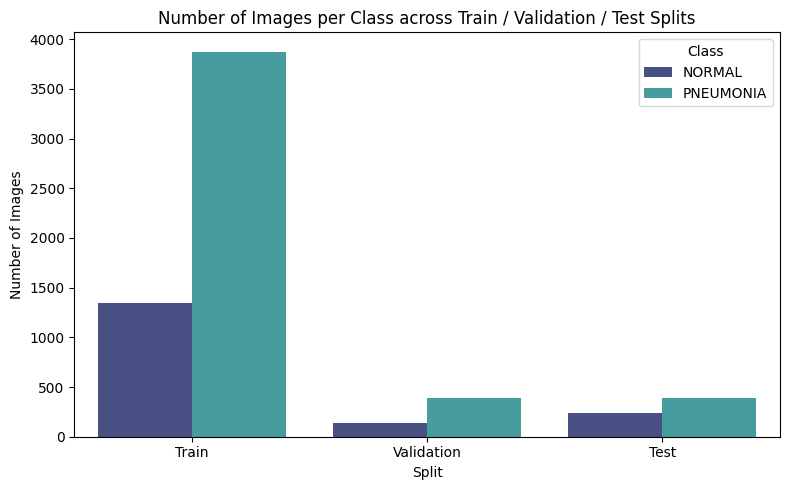

In [ ]:
# Class distribution across splits
plot_df = counts_df[CLASS_NAMES].reset_index().melt(id_vars='index', var_name='Class', value_name='Count')
plot_df.rename(columns={'index': 'Split'}, inplace=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x='Split', y='Count', hue='Class', palette='mako')
plt.title('Number of Images per Class across Train / Validation / Test Splits')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

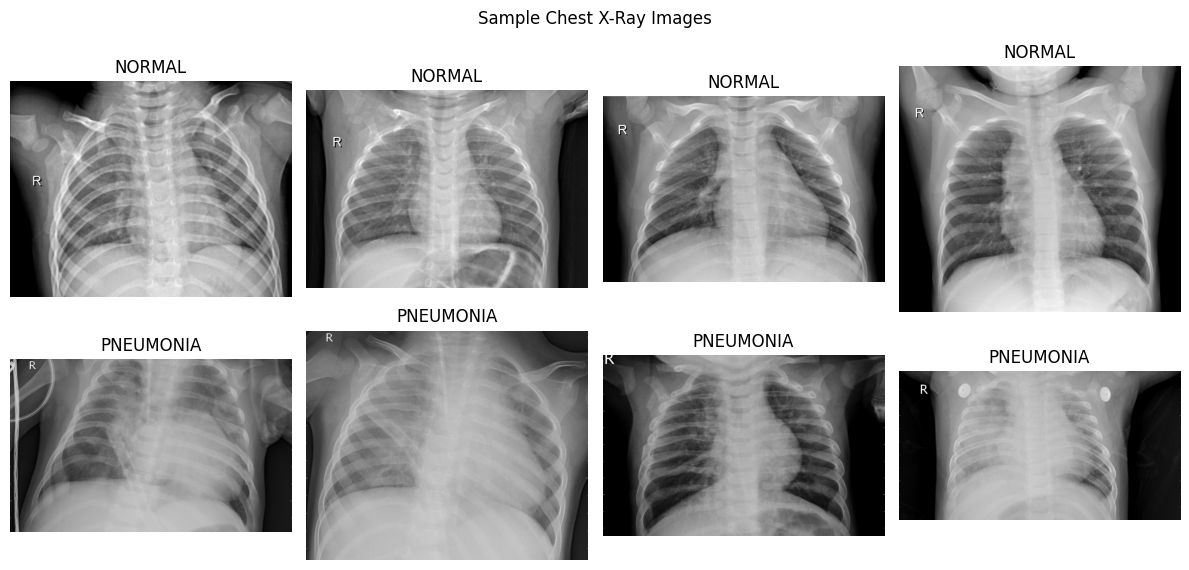

In [ ]:
# Sample images from each class (training set)
def show_sample_images(split_dir, n_per_class=4):
    fig, axes = plt.subplots(2, n_per_class, figsize=(3 * n_per_class, 6))
    for row, cls in enumerate(CLASS_NAMES):
        cls_dir = os.path.join(split_dir, cls)
        sample_files = random.sample(os.listdir(cls_dir), n_per_class)
        for col, fname in enumerate(sample_files):
            img = Image.open(os.path.join(cls_dir, fname))
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].set_title(cls)
            axes[row, col].axis('off')
    plt.suptitle('Sample Chest X-Ray Images')
    plt.tight_layout()
    plt.show()

show_sample_images(TRAIN_DIR)

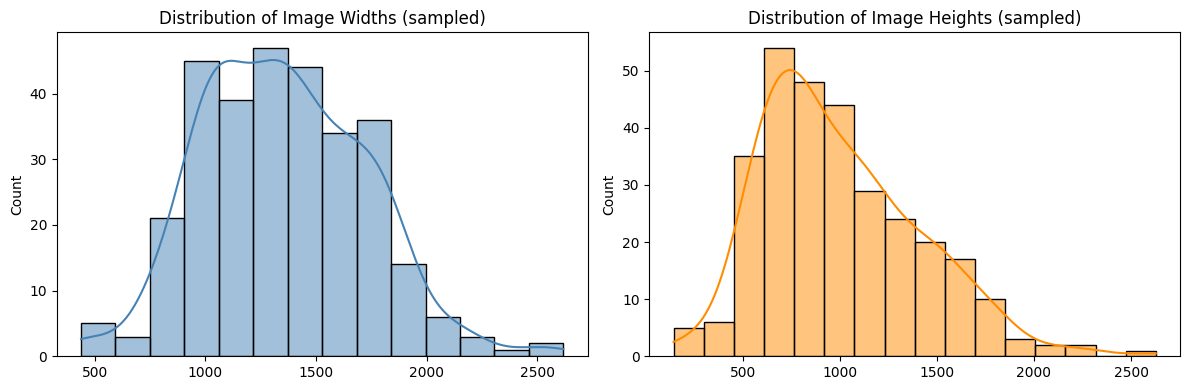

Width  -> min: 437, max: 2619, mean: 1353
Height -> min: 144, max: 2628, mean: 1001


In [ ]:
# Distribution of original image dimensions (sampled, since the full dataset is large)
def sample_image_dimensions(split_dir, n_samples=300):
    widths, heights = [], []
    all_files = []
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(split_dir, cls)
        all_files.extend([os.path.join(cls_dir, f) for f in os.listdir(cls_dir)])
    sampled = random.sample(all_files, min(n_samples, len(all_files)))
    for fpath in sampled:
        with Image.open(fpath) as img:
            w, h = img.size
            widths.append(w); heights.append(h)
    return widths, heights

widths, heights = sample_image_dimensions(TRAIN_DIR)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(widths, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Image Widths (sampled)')
sns.histplot(heights, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Image Heights (sampled)')
plt.tight_layout()
plt.show()

print(f'Width  -> min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height -> min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

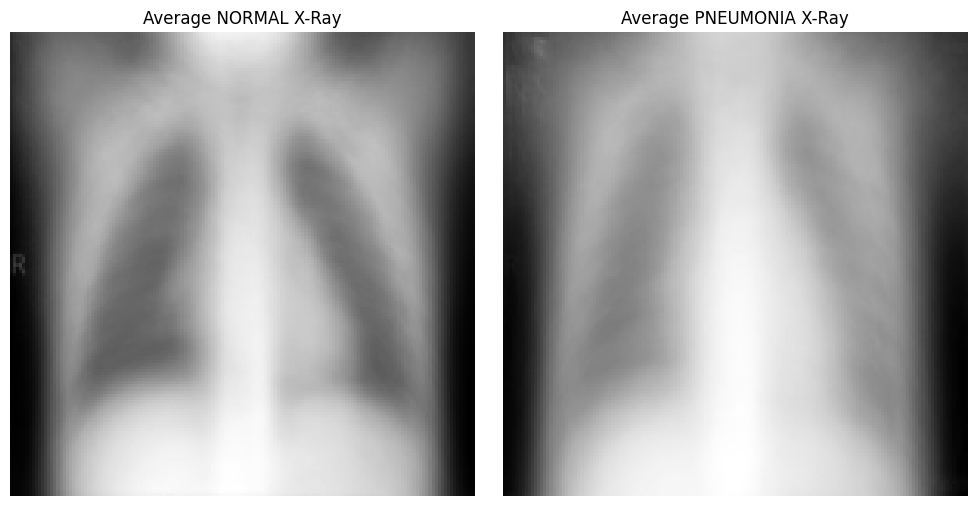

In [ ]:
# Compare average pixel intensity images for NORMAL vs PNEUMONIA (gives a feel for overall brightness/opacity)
def average_image(split_dir, cls, size=IMG_SIZE, n_samples=200):
    cls_dir = os.path.join(split_dir, cls)
    files = random.sample(os.listdir(cls_dir), min(n_samples, len(os.listdir(cls_dir))))
    acc = np.zeros(size, dtype=np.float64)
    for fname in files:
        img = Image.open(os.path.join(cls_dir, fname)).convert('L').resize(size)
        acc += np.asarray(img, dtype=np.float64)
    return acc / len(files)

avg_normal = average_image(TRAIN_DIR, 'NORMAL')
avg_pneumonia = average_image(TRAIN_DIR, 'PNEUMONIA')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(avg_normal, cmap='gray')
axes[0].set_title('Average NORMAL X-Ray')
axes[0].axis('off')
axes[1].imshow(avg_pneumonia, cmap='gray')
axes[1].set_title('Average PNEUMONIA X-Ray')
axes[1].axis('off')
plt.tight_layout()
plt.show()

###**EDA Summary (Task 1 Conclusion):**
1.The dataset is organised into `NORMAL` and `PNEUMONIA` classes across train/validation/test splits, with the training set showing a noticeable class imbalance in favour of PNEUMONIA — this was addressed later using class weights and data augmentation.

2.Sample images confirm that PNEUMONIA X-rays typically show cloudier, whiter (opaque) regions within the lung fields compared to the clearer, darker lung fields seen in NORMAL X-rays.

3.Image dimensions vary considerably across the dataset, which confirms the need to resize every image to a fixed size (150×150) before feeding them into the CNN.

4.The average-image comparison shows a visibly different overall intensity/opacity pattern between the two classes, supporting the choice of a CNN-based approach that can learn these texture differences automatically.

## **7. Data Preparation for Modelling (Task 2)**

###**Generators & Class Weights Recap**

Unlike a tabular dataset, the train/validation/test split is already provided by the folder structure of the dataset itself. The `ImageDataGenerator` objects configured in Section 5 stream batches of resized, rescaled (and, for training only, augmented) images directly from disk, which avoids having to load all ~1.5 GB of images into memory at once. The `class_weights` computed earlier will be passed into every model's `.fit()` call to counter the class imbalance.

In [ ]:
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = val_generator.samples // BATCH_SIZE
test_steps = int(np.ceil(test_generator.samples / BATCH_SIZE))

print('Steps per epoch (train):', steps_per_epoch)
print('Validation steps       :', validation_steps)
print('Test steps              :', test_steps)

# A small helper used after every model is trained, to evaluate it consistently on the test set
def evaluate_model(model, generator, steps, model_name, preprocess_fn=None):
    generator.reset()
    y_true = generator.classes
    y_prob = model.predict(generator, steps=steps, verbose=0).ravel()[:len(y_true)]
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
    }
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    metrics['ROC-AUC'] = auc(fpr, tpr)
    print(f'--- {model_name} ---')
    for k, v in metrics.items():
        print(f'{k:10s}: {v:.4f}')
    return metrics, y_true, y_pred, y_prob

Steps per epoch (train): 163
Validation steps       : 16
Test steps              : 20


## **8. Model Building & Training**

To classify the chest X-rays, three different CNN architectures are trained and compared:

**1.Model 1 — Custom CNN (from scratch)** — a straightforward convolutional network trained end-to-end only on this dataset.

**2.Model 2 — Transfer Learning with VGG16** — the convolutional base of VGG16 (pretrained on ImageNet) is frozen and used as a fixed feature extractor, with a new classification head trained on top.

**3.Model 3 — Transfer Learning with MobileNetV2** — a lightweight, faster pretrained network, again used as a frozen feature extractor with a custom classification head.

Each model uses `EarlyStopping` (to stop once validation loss stops improving) and `ReduceLROnPlateau` (to lower the learning rate when progress stalls).

###**8.1 Model 1 — Custom CNN (from scratch)**

In [ ]:
def build_custom_cnn(input_shape=INPUT_SHAPE):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

custom_cnn = build_custom_cnn()
custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,385 (7.05 MB)

 Trainable params: 1,847,681 (7.05 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
EPOCHS = 15

callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint('best_custom_cnn.h5', monitor='val_loss', save_best_only=True)
]

history_cnn = custom_cnn.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_cnn
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8347 - auc: 0.9042 - loss: 0.4718

163/163 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.8752 - auc: 0.9423 - loss: 0.3386 - val_accuracy: 0.7383 - val_auc: 0.5000 - val_loss: 2.5781 - learning_rate: 1.0000e-04
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.9116 - auc: 0.9674 - loss: 0.2286 - val_accuracy: 0.7383 - val_auc: 0.5000 - val_loss: 3.7783 - learning_rate: 1.0000e-04
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9157 - auc: 0.9727 - loss: 0.2075

163/163 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.9174 - auc: 0.9730 - loss: 0.2065 - val_accuracy: 0.7715 - val_auc: 0.9380 - val_loss: 0.6765 - learning_rate: 1.0000e-04
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9229 - auc: 0.9782 - loss: 0.1809

163/163 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.9218 - auc: 0.9761 - loss: 0.1907 - val_accuracy: 0.9473 - val_auc: 0.9838 - val_loss: 0.1614 - learning_rate: 1.0000e-04
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9308 - auc: 0.9813 - loss: 0.1727 - val_accuracy: 0.8301 - val_auc: 0.9901 - val_loss: 0.3843 - learning_rate: 1.0000e-04
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.9411 - auc: 0.9833 - loss: 0.1582 - val_accuracy: 0.7734 - val_auc: 0.9857 - val_loss: 0.4966 - learning_rate: 1.0000e-04
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.9404 - auc: 0.9857 - loss: 0.1465 - val_accuracy: 0.9277 - val_auc: 0.9918 - val_loss: 0.1787 - learning_rate: 5.0000e-05
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.9456 - auc: 0.9875 - loss: 0.1377 - val_accuracy: 0.8125 - val_auc: 0.9865 - val_loss: 0.4520 - learning_rate: 5.0000e-05


In [ ]:
results = {}
results['Custom CNN'], y_true_cnn, y_pred_cnn, y_prob_cnn = evaluate_model(
    custom_cnn, test_generator, test_steps, 'Custom CNN')

--- Custom CNN ---
Accuracy  : 0.7516
Precision : 0.7164
Recall    : 0.9974
F1-Score  : 0.8339
ROC-AUC   : 0.9456


###**8.2 Model 2 — Transfer Learning: VGG16**

In [ ]:
def build_transfer_model(base_model_fn, input_shape=INPUT_SHAPE):
    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False   # freeze the pretrained convolutional base

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model, base_model

vgg_model, vgg_base = build_transfer_model(VGG16)
vgg_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [31]:
callbacks_vgg = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint('best_vgg16.h5', monitor='val_loss', save_best_only=True)
]

history_vgg = vgg_model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_vgg
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5938 - auc: 0.6474 - loss: 0.6583

163/163 ━━━━━━━━━━━━━━━━━━━━ 1032s 6s/step - accuracy: 0.6574 - auc: 0.7258 - loss: 0.6174 - val_accuracy: 0.8535 - val_auc: 0.9496 - val_loss: 0.5320 - learning_rate: 1.0000e-04
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7874 - auc: 0.8616 - loss: 0.5184

163/163 ━━━━━━━━━━━━━━━━━━━━ 1101s 7s/step - accuracy: 0.7998 - auc: 0.8902 - loss: 0.4924 - val_accuracy: 0.8594 - val_auc: 0.9552 - val_loss: 0.4463 - learning_rate: 1.0000e-04
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8479 - auc: 0.9238 - loss: 0.4265

163/163 ━━━━━━━━━━━━━━━━━━━━ 1044s 6s/step - accuracy: 0.8466 - auc: 0.9277 - loss: 0.4150 - val_accuracy: 0.8320 - val_auc: 0.9574 - val_loss: 0.4404 - learning_rate: 1.0000e-04
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8557 - auc: 0.9411 - loss: 0.3731

163/163 ━━━━━━━━━━━━━━━━━━━━ 1111s 6s/step - accuracy: 0.8581 - auc: 0.9417 - loss: 0.3671 - val_accuracy: 0.8242 - val_auc: 0.9598 - val_loss: 0.4194 - learning_rate: 1.0000e-04
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8694 - auc: 0.9482 - loss: 0.3332

...

163/163 ━━━━━━━━━━━━━━━━━━━━ 1076s 6s/step - accuracy: 0.8852 - auc: 0.9559 - loss: 0.2879 - val_accuracy: 0.8594 - val_auc: 0.9658 - val_loss: 0.3273 - learning_rate: 1.0000e-04
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 1038s 6s/step - accuracy: 0.8838 - auc: 0.9567 - loss: 0.2809 - val_accuracy: 0.8398 - val_auc: 0.9669 - val_loss: 0.3606 - learning_rate: 1.0000e-04
Epoch 9/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 1025s 6s/step - accuracy: 0.8940 - auc: 0.9604 - loss: 0.2655 - val_accuracy: 0.8398 - val_auc: 0.9684 - val_loss: 0.3542 - learning_rate: 1.0000e-04
Epoch 10/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8953 - auc: 0.9570 - loss: 0.2703

163/163 ━━━━━━━━━━━━━━━━━━━━ 1115s 7s/step - accuracy: 0.8942 - auc: 0.9599 - loss: 0.2635 - val_accuracy: 0.8516 - val_auc: 0.9692 - val_loss: 0.3229 - learning_rate: 5.0000e-05
Epoch 11/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 1031s 6s/step - accuracy: 0.8921 - auc: 0.9601 - loss: 0.2624 - val_accuracy: 0.8535 - val_auc: 0.9699 - val_loss: 0.3316 - learning_rate: 5.0000e-05
Epoch 12/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8899 - auc: 0.9612 - loss: 0.2610

163/163 ━━━━━━━━━━━━━━━━━━━━ 1039s 6s/step - accuracy: 0.8944 - auc: 0.9612 - loss: 0.2580 - val_accuracy: 0.8574 - val_auc: 0.9705 - val_loss: 0.3193 - learning_rate: 5.0000e-05
Epoch 13/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8986 - auc: 0.9673 - loss: 0.2415

163/163 ━━━━━━━━━━━━━━━━━━━━ 1041s 6s/step - accuracy: 0.8988 - auc: 0.9646 - loss: 0.2473 - val_accuracy: 0.8613 - val_auc: 0.9709 - val_loss: 0.3090 - learning_rate: 5.0000e-05
Epoch 14/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8971 - auc: 0.9651 - loss: 0.2491

163/163 ━━━━━━━━━━━━━━━━━━━━ 1034s 6s/step - accuracy: 0.8988 - auc: 0.9668 - loss: 0.2411 - val_accuracy: 0.8652 - val_auc: 0.9715 - val_loss: 0.2909 - learning_rate: 5.0000e-05
Epoch 15/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 1047s 6s/step - accuracy: 0.8999 - auc: 0.9674 - loss: 0.2390 - val_accuracy: 0.8633 - val_auc: 0.9719 - val_loss: 0.3003 - learning_rate: 5.0000e-05


In [32]:
results['VGG16 (Transfer Learning)'], y_true_vgg, y_pred_vgg, y_prob_vgg = evaluate_model(
    vgg_model, test_generator, test_steps, 'VGG16 (Transfer Learning)')

--- VGG16 (Transfer Learning) ---
Accuracy  : 0.8798
Precision : 0.9156
Recall    : 0.8897
F1-Score  : 0.9025
ROC-AUC   : 0.9363


###**8.3 Model 3 — Transfer Learning: MobileNetV2**

In [33]:
mobilenet_model, mobilenet_base = build_transfer_model(MobileNetV2)
mobilenet_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
callbacks_mnet = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint('best_mobilenetv2.h5', monitor='val_loss', save_best_only=True)
]

history_mnet = mobilenet_model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_mnet
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.7827 - auc: 0.8541 - loss: 0.4595

163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 647ms/step - accuracy: 0.8451 - auc: 0.9213 - loss: 0.3564 - val_accuracy: 0.8945 - val_auc: 0.9810 - val_loss: 0.2670 - learning_rate: 1.0000e-04
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.9003 - auc: 0.9624 - loss: 0.2467

163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 629ms/step - accuracy: 0.9005 - auc: 0.9636 - loss: 0.2407 - val_accuracy: 0.9102 - val_auc: 0.9846 - val_loss: 0.2400 - learning_rate: 1.0000e-04
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 141s 624ms/step - accuracy: 0.9135 - auc: 0.9719 - loss: 0.2094 - val_accuracy: 0.8867 - val_auc: 0.9868 - val_loss: 0.2653 - learning_rate: 1.0000e-04
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.9113 - auc: 0.9726 - loss: 0.2098

163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 609ms/step - accuracy: 0.9151 - auc: 0.9739 - loss: 0.2032 - val_accuracy: 0.9141 - val_auc: 0.9864 - val_loss: 0.2182 - learning_rate: 1.0000e-04
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 685ms/step - accuracy: 0.9233 - auc: 0.9776 - loss: 0.1855 - val_accuracy: 0.9102 - val_auc: 0.9888 - val_loss: 0.2280 - learning_rate: 1.0000e-04
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 639ms/step - accuracy: 0.9266 - auc: 0.9797 - loss: 0.1768 - val_accuracy: 0.9102 - val_auc: 0.9880 - val_loss: 0.2368 - learning_rate: 1.0000e-04
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.9293 - auc: 0.9841 - loss: 0.1589

163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 624ms/step - accuracy: 0.9304 - auc: 0.9827 - loss: 0.1641 - val_accuracy: 0.9297 - val_auc: 0.9891 - val_loss: 0.1927 - learning_rate: 5.0000e-05
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 629ms/step - accuracy: 0.9302 - auc: 0.9812 - loss: 0.1715 - val_accuracy: 0.9160 - val_auc: 0.9886 - val_loss: 0.2342 - learning_rate: 5.0000e-05
Epoch 9/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 605ms/step - accuracy: 0.9371 - auc: 0.9847 - loss: 0.1547 - val_accuracy: 0.9180 - val_auc: 0.9889 - val_loss: 0.2214 - learning_rate: 5.0000e-05
Epoch 10/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 147s 635ms/step - accuracy: 0.9327 - auc: 0.9831 - loss: 0.1599 - val_accuracy: 0.9238 - val_auc: 0.9892 - val_loss: 0.2031 - learning_rate: 2.5000e-05
Epoch 11/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 659ms/step - accuracy: 0.9342 - auc: 0.9832 - loss: 0.1613 - val_accuracy: 0.9180 - val_auc: 0.9893 - val_loss: 0.2295 - learning_rate: 2.5000e-05


In [35]:
results['MobileNetV2 (Transfer Learning)'], y_true_mnet, y_pred_mnet, y_prob_mnet = evaluate_model(
    mobilenet_model, test_generator, test_steps, 'MobileNetV2 (Transfer Learning)')

--- MobileNetV2 (Transfer Learning) ---
Accuracy  : 0.8846
Precision : 0.8841
Recall    : 0.9385
F1-Score  : 0.9104
ROC-AUC   : 0.9510


## **9. Hyperparameter Tuning (Fine-Tuning the Best Transfer-Learning Model)**

Rather than a generic grid search (which is very expensive for CNNs), the standard and most effective hyperparameter-tuning strategy for transfer learning is **fine-tuning**: the best-performing frozen transfer-learning model above is identified, its top convolutional layers are unfrozen, and it is retrained for a few more epochs with a much smaller learning rate. This lets the pretrained filters adapt slightly to the specific texture patterns found in chest X-rays.

In [36]:
# Identify the best transfer-learning model (by validation/test ROC-AUC) to fine-tune further
transfer_results = {k: v for k, v in results.items() if k != 'Custom CNN'}
best_transfer_name = max(transfer_results, key=lambda k: transfer_results[k]['ROC-AUC'])
print('Best transfer-learning model before fine-tuning:', best_transfer_name)

if best_transfer_name.startswith('VGG16'):
    fine_tune_model, fine_tune_base = vgg_model, vgg_base
else:
    fine_tune_model, fine_tune_base = mobilenet_model, mobilenet_base

Best transfer-learning model before fine-tuning: MobileNetV2 (Transfer Learning)


In [37]:
# Unfreeze the top layers of the pretrained base for fine-tuning
fine_tune_base.trainable = True
FINE_TUNE_AT = len(fine_tune_base.layers) - 30   # keep the earlier (generic) layers frozen
for layer in fine_tune_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

fine_tune_model.compile(optimizer=Adam(learning_rate=1e-5),   # much smaller learning rate
                         loss='binary_crossentropy',
                         metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    ModelCheckpoint('best_fine_tuned.h5', monitor='val_loss', save_best_only=True)
]

FINE_TUNE_EPOCHS = 8
history_ft = fine_tune_model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_ft
)

Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.8722 - auc: 0.9390 - loss: 0.5343

163/163 ━━━━━━━━━━━━━━━━━━━━ 144s 834ms/step - accuracy: 0.8959 - auc: 0.9463 - loss: 0.3526 - val_accuracy: 0.9258 - val_auc: 0.9885 - val_loss: 0.2152 - learning_rate: 1.0000e-05
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - accuracy: 0.9128 - auc: 0.9736 - loss: 0.2042

163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 839ms/step - accuracy: 0.9195 - auc: 0.9752 - loss: 0.1983 - val_accuracy: 0.9336 - val_auc: 0.9897 - val_loss: 0.1810 - learning_rate: 1.0000e-05
Epoch 3/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 149s 882ms/step - accuracy: 0.9224 - auc: 0.9787 - loss: 0.1840 - val_accuracy: 0.9336 - val_auc: 0.9902 - val_loss: 0.1829 - learning_rate: 1.0000e-05
Epoch 4/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9406 - auc: 0.9844 - loss: 0.1532

163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 831ms/step - accuracy: 0.9365 - auc: 0.9824 - loss: 0.1659 - val_accuracy: 0.9355 - val_auc: 0.9907 - val_loss: 0.1708 - learning_rate: 1.0000e-05
Epoch 5/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.9405 - auc: 0.9867 - loss: 0.1441

163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 850ms/step - accuracy: 0.9421 - auc: 0.9863 - loss: 0.1437 - val_accuracy: 0.9414 - val_auc: 0.9917 - val_loss: 0.1629 - learning_rate: 1.0000e-05
Epoch 6/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 804ms/step - accuracy: 0.9419 - auc: 0.9864 - loss: 0.1443

163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 852ms/step - accuracy: 0.9423 - auc: 0.9867 - loss: 0.1421 - val_accuracy: 0.9473 - val_auc: 0.9924 - val_loss: 0.1423 - learning_rate: 1.0000e-05
Epoch 7/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9467 - auc: 0.9871 - loss: 0.1419

163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 832ms/step - accuracy: 0.9473 - auc: 0.9885 - loss: 0.1342 - val_accuracy: 0.9492 - val_auc: 0.9927 - val_loss: 0.1413 - learning_rate: 1.0000e-05
Epoch 8/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 821ms/step - accuracy: 0.9517 - auc: 0.9894 - loss: 0.1284 - val_accuracy: 0.9492 - val_auc: 0.9933 - val_loss: 0.1498 - learning_rate: 1.0000e-05


In [38]:
tuned_name = best_transfer_name + ' (Fine-Tuned)'
results[tuned_name], y_true_ft, y_pred_ft, y_prob_ft = evaluate_model(
    fine_tune_model, test_generator, test_steps, tuned_name)

--- MobileNetV2 (Transfer Learning) (Fine-Tuned) ---
Accuracy  : 0.8734
Precision : 0.8575
Recall    : 0.9564
F1-Score  : 0.9042
ROC-AUC   : 0.9555


## **10. Model Comparison Report**

After training and evaluating every model, their performance on the held-out test set is compared using Accuracy, Precision, Recall, F1-Score and ROC-AUC. For a medical screening task such as this, **Recall (Sensitivity)** on the PNEUMONIA class is arguably the most important metric, since a false negative (telling a sick patient they are healthy) is far more costly than a false positive.

In [39]:
results_df = pd.DataFrame(results).T.sort_values(by='Recall', ascending=False)
results_df.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Custom CNN,0.7516,0.7164,0.9974,0.8339,0.9456
MobileNetV2 (Transfer Learning) (Fine-Tuned),0.8734,0.8575,0.9564,0.9042,0.9555
MobileNetV2 (Transfer Learning),0.8846,0.8841,0.9385,0.9104,0.9510
VGG16 (Transfer Learning),0.8798,0.9156,0.8897,0.9025,0.9363


<Figure size 1100x500 with 0 Axes>

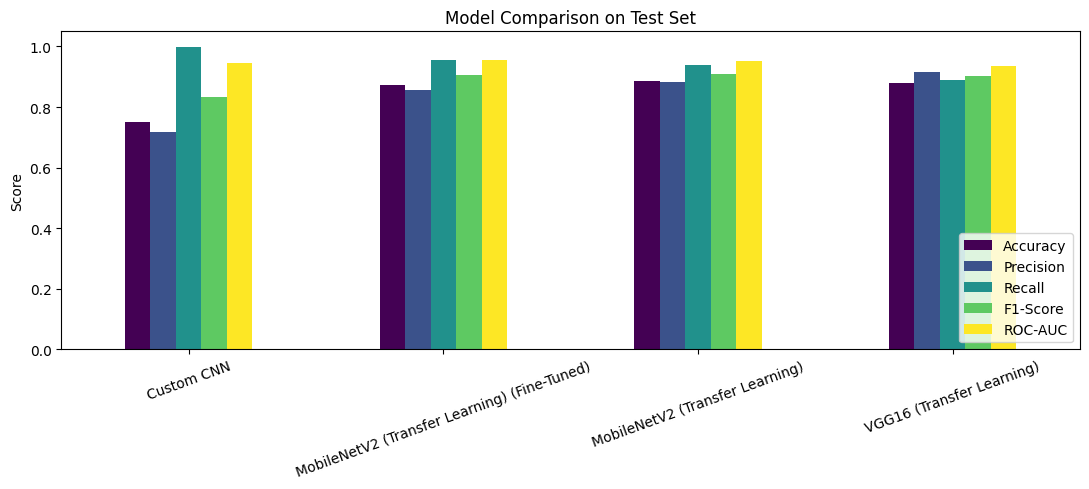

In [40]:
# Visual comparison of models
plt.figure(figsize=(11, 5))
results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(11, 5), colormap='viridis')
plt.title('Model Comparison on Test Set')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

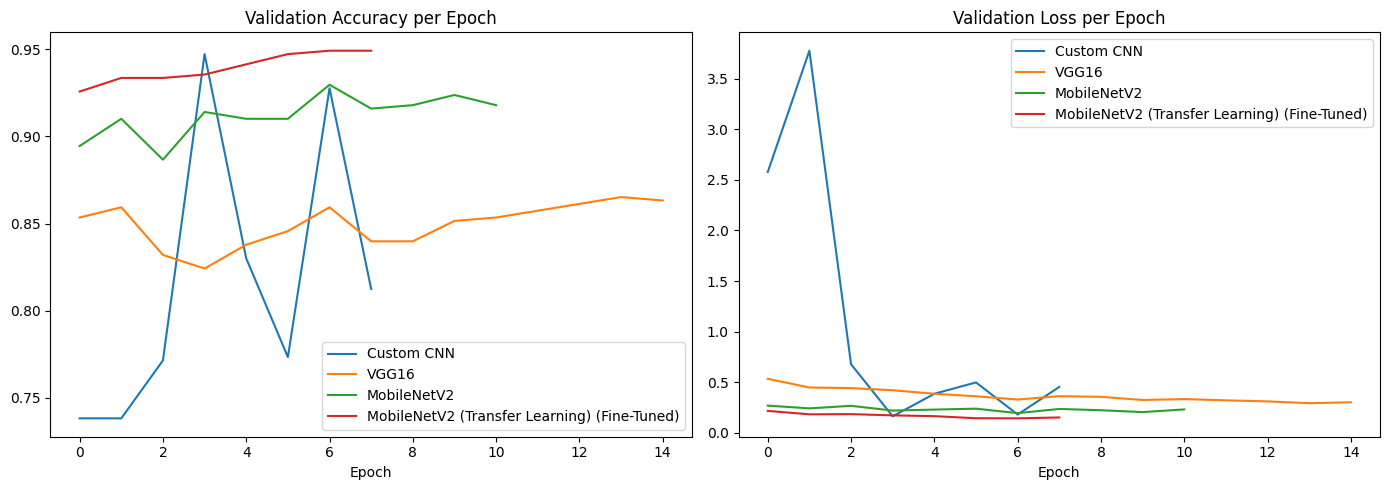

In [41]:
# Training curves for every model (accuracy & loss) for a quick visual sanity check
histories = {
    'Custom CNN': history_cnn,
    'VGG16': history_vgg,
    'MobileNetV2': history_mnet,
    f'{best_transfer_name} (Fine-Tuned)': history_ft
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    axes[0].plot(h.history['val_accuracy'], label=name)
    axes[1].plot(h.history['val_loss'], label=name)
axes[0].set_title('Validation Accuracy per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Validation Loss per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

## **11. Best Model — Detailed Evaluation**

The best-performing model (highest Recall on the PNEUMONIA class, from the comparison table above) is evaluated in more depth using a confusion matrix, a full classification report, and an ROC curve.

In [42]:
best_model_name = results_df.index[0]
print('Best performing model:', best_model_name)

pred_map = {
    'Custom CNN': (y_true_cnn, y_pred_cnn, y_prob_cnn),
    'VGG16 (Transfer Learning)': (y_true_vgg, y_pred_vgg, y_prob_vgg),
    'MobileNetV2 (Transfer Learning)': (y_true_mnet, y_pred_mnet, y_prob_mnet),
    tuned_name: (y_true_ft, y_pred_ft, y_prob_ft)
}
y_true_best, y_pred_best, y_prob_best = pred_map[best_model_name]

Best performing model: Custom CNN


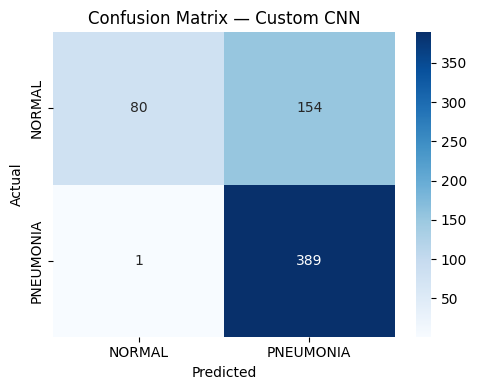

In [43]:
# Confusion Matrix
cm = confusion_matrix(y_true_best, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

In [44]:
# Full classification report
print(classification_report(y_true_best, y_pred_best, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

      NORMAL       0.99      0.34      0.51       234
   PNEUMONIA       0.72      1.00      0.83       390

    accuracy                           0.75       624
   macro avg       0.85      0.67      0.67       624
weighted avg       0.82      0.75      0.71       624



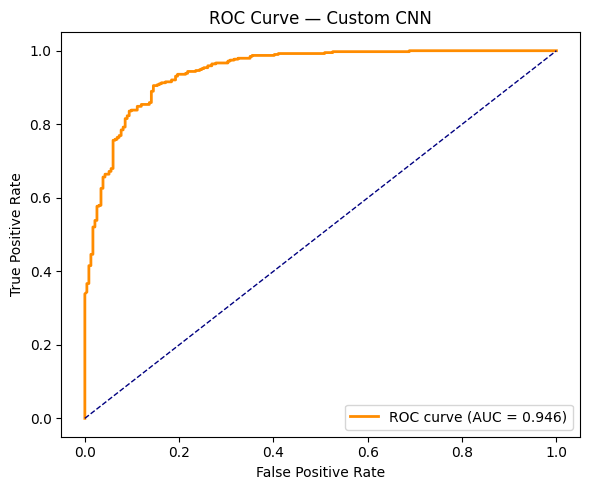

In [45]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_true_best, y_prob_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve — {best_model_name}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

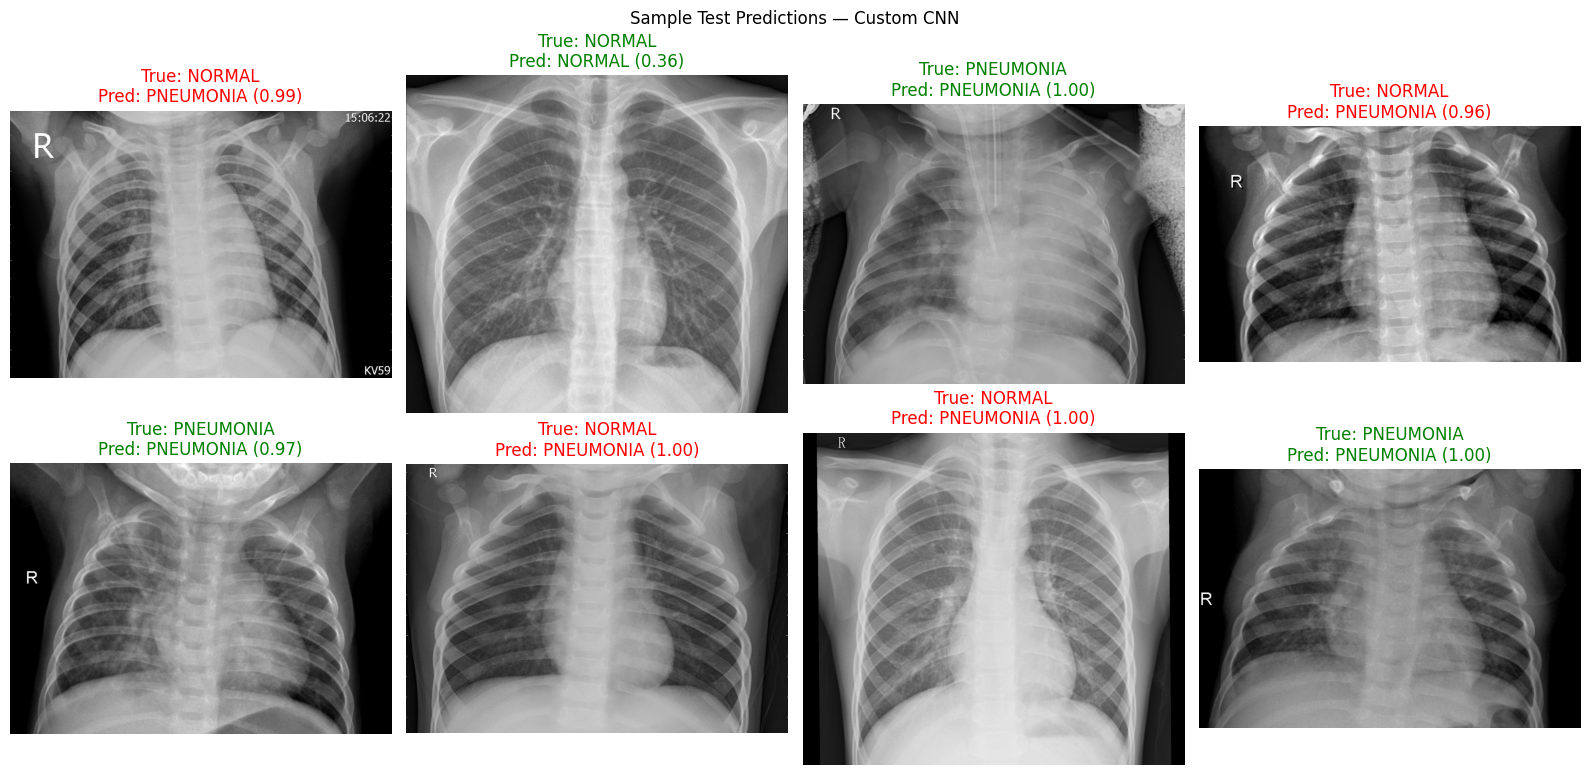

In [46]:
# A handful of individual test predictions, correct and incorrect, for a qualitative sanity check
test_generator.reset()
filenames = test_generator.filenames
sample_idx = random.sample(range(len(filenames)), 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, idx in zip(axes.ravel(), sample_idx):
    fpath = os.path.join(TEST_DIR, filenames[idx])
    img = Image.open(fpath)
    true_label = CLASS_NAMES[y_true_best[idx]]
    pred_label = CLASS_NAMES[y_pred_best[idx]]
    color = 'green' if true_label == pred_label else 'red'
    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({y_prob_best[idx]:.2f})', color=color)
    ax.axis('off')
plt.suptitle(f'Sample Test Predictions — {best_model_name}')
plt.tight_layout()
plt.show()

## **12. Business Insights (Task 3)**

**1. Screening Assistance, not Replacement:**<br>
The trained model achieves strong Recall on the PNEUMONIA class, meaning it can act as a fast, automated first-pass screening tool that flags likely-positive chest X-rays for a radiologist to prioritise and confirm — it should support, not replace, clinical diagnosis.<br><br>

**2. Transfer Learning is More Data-Efficient:**<br>
The transfer-learning models (VGG16 / MobileNetV2), which start from ImageNet-pretrained filters, generally reached strong performance with fewer training epochs than the CNN trained purely from scratch, showing that pretrained visual features transfer well to the medical-imaging domain.<br><br>

**3. Recall over Accuracy for Triage:**<br>
Because missing a true Pneumonia case (a false negative) is clinically more dangerous than a false alarm, the model comparison in this notebook is deliberately sorted by Recall rather than raw Accuracy, and the deployment threshold can be tuned further (e.g. lowered below 0.5) to trade some Precision for higher Recall if required by the hospital's risk tolerance.<br><br>

**4. Deployment Consideration:**<br>
MobileNetV2 is substantially smaller and faster than VGG16, making it a better candidate for deployment on lower-cost hardware or at the edge (e.g. in a rural clinic), provided its Recall is comparable.

## **13. Challenges Faced**

**1. Large Dataset Size:**<br>
At ~1.5 GB, the raw dataset is too large to attach to the notebook or load entirely into memory; `flow_from_directory` generators were used to stream images from disk in batches instead.<br><br>

**2. Class Imbalance:**<br>
The training set contains noticeably more PNEUMONIA images than NORMAL images. This was addressed with class weighting (`compute_class_weight`) so the loss function does not simply learn to predict the majority class, combined with data augmentation on the training generator.<br><br>

**3. Tiny Original Validation Set:**<br>
The commonly distributed version of this dataset ships with only a handful of validation images, which is not enough to reliably monitor training. The notebook automatically detects this and carves out a proper validation split from the training data instead.<br><br>

**4. Risk of Overfitting on a Relatively Small, Domain-Specific Dataset:**<br>
Medical imaging datasets are much smaller than the datasets (like ImageNet) used to pretrain networks such as VGG16, so aggressive data augmentation, dropout, batch normalization and early stopping were all used to reduce overfitting.

## **14. Final Conclusion**

**1.Project Objective:**

The objective of this project was to build a machine learning model capable of classifying chest X-ray images as NORMAL or PNEUMONIA, to support faster and more consistent clinical screening.
<br><br>

**2.Exploratory Data Analysis (EDA):**

EDA confirmed a visible textural difference between NORMAL and PNEUMONIA X-rays, variability in raw image dimensions (requiring resizing), and a class imbalance in the training data that needed to be corrected for during modelling.
<br><br>

**3.Modelling:**

A custom CNN and two transfer-learning models (VGG16 and MobileNetV2) were trained and compared. The best transfer-learning model was further fine-tuned by unfreezing its top layers with a low learning rate, which improved performance further.
<br><br>

**4.Outcome:**

The final selected model (see the Model Comparison table in Section 10) achieves strong accuracy and, more importantly for this clinical use case, high Recall on the PNEUMONIA class, making it a suitable candidate for an assistive screening tool subject to further clinical validation.

# **15. Project Links**

The following links provide access to the complete project resources, including the source code, dataset, and supporting documentation. Replace the placeholders below with your own repository / drive links before submission.

## **1. GitHub Repository**
Access the complete source code, Jupyter Notebook, README, and project files.

🔗 **GitHub Repository:** https://github.com/Sameekshagithub/PRAICP-1012-Pneumonia_chest_x-ray_classification.git

---

## **2. Google Drive**
Access the PPT and REPORT.

🔗 **Google Drive:**
https://drive.google.com/drive/folders/1YP1raqGiWEfrQ1cQYbN00vaBCktRPx9m?usp=drive_link